# Análise da precipitação ao longo do ano

**Anos analisados:** 2019, 2020

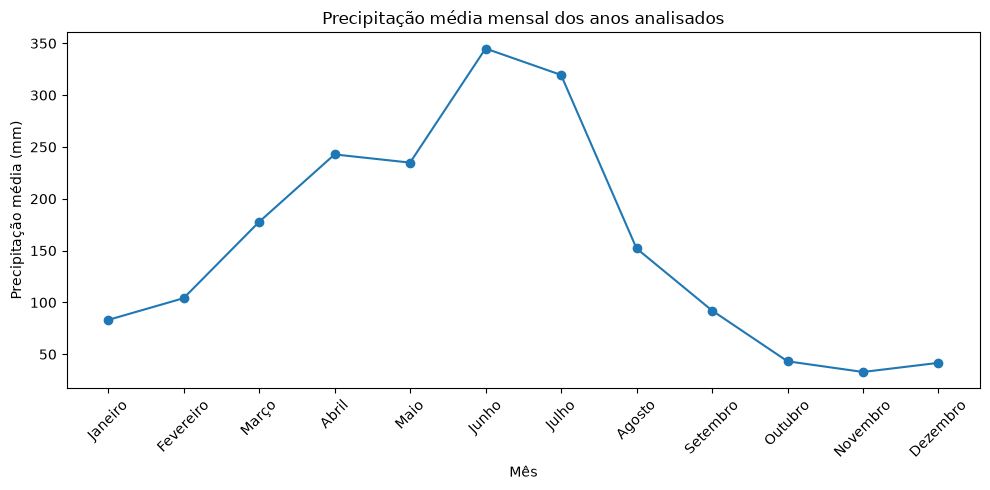

### Precipitação média por mês

,Mês,Precipitação média (mm)
0,Janeiro,83.1
1,Fevereiro,104.1
2,Março,177.7
3,Abril,242.8
4,Maio,234.9
5,Junho,345.0
6,Julho,319.5
7,Agosto,152.1
8,Setembro,92.2
9,Outubro,43.2


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Título
display(Markdown("# Análise da precipitação ao longo do ano"))

# Carregar o dataset
df = pd.read_csv(
    "../dados/df_recife.csv",
    sep=",",
    encoding="utf-8"
)

# Remover espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

# Remover coluna de índice, caso exista
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Converter a coluna Data para data
df["Data"] = pd.to_datetime(
    df["Data"],
    errors="coerce"
)

# Converter precipitação para número
col_precipitacao = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"

df[col_precipitacao] = (
    df[col_precipitacao]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df[col_precipitacao] = pd.to_numeric(
    df[col_precipitacao],
    errors="coerce"
)

# Remover registros sem data ou precipitação
df = df.dropna(
    subset=["Data", col_precipitacao]
)

# Criar colunas de Ano e Mês
df["Ano"] = df["Data"].dt.year
df["Mês"] = df["Data"].dt.month

# Mostrar os anos encontrados no dataset
anos = sorted(df["Ano"].unique())

display(
    Markdown(
        f"**Anos analisados:** {', '.join(map(str, anos))}"
    )
)

# Somar a precipitação de cada mês em cada ano
precipitacao_por_ano = df.groupby(
    ["Ano", "Mês"]
)[col_precipitacao].sum()

# Calcular a média da precipitação dos anos para cada mês
precipitacao_mensal = precipitacao_por_ano.groupby(
    "Mês"
).mean()

# Nomes dos meses
nomes_meses = [
    "Janeiro",
    "Fevereiro",
    "Março",
    "Abril",
    "Maio",
    "Junho",
    "Julho",
    "Agosto",
    "Setembro",
    "Outubro",
    "Novembro",
    "Dezembro"
]

# Garantir que todos os meses apareçam
precipitacao_mensal = precipitacao_mensal.reindex(
    range(1, 13),
    fill_value=0
)

# ==========================
# GRÁFICO
# ==========================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    nomes_meses,
    precipitacao_mensal.values,
    marker="o"
)

ax.set_title(
    "Precipitação média mensal dos anos analisados"
)

ax.set_xlabel("Mês")

ax.set_ylabel(
    "Precipitação média (mm)"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================
# TABELA
# ==========================

display(
    Markdown(
        "### Precipitação média por mês"
    )
)

tabela = pd.DataFrame({
    "Mês": nomes_meses,
    "Precipitação média (mm)": precipitacao_mensal.values
})

display(tabela)